# Examen Corto 1 

Integrantes
- Francis Aguilar 
- José Marchena

Link del repositorio: https://github.com/faguilarleal/EC1-VC 



## Task 1

Imagine que está diseñando el primer bloque de una arquitectura convolucional para procesar imágenes
satelitales multiespectrales de entrada con dimensiones 𝑊 = 256, 𝐻 = 256, 𝐶 = 4 (RGB + Infrarrojo). Tiene
dos opciones de diseño para este primer bloque, asumiendo que ambas buscan extraer 64 canales de salida
(𝐶𝑜𝑢𝑡 = 64):

- Opción A (Estilo AlexNet): Una capa convolucional con filtros de 7 × 7, stride de 2 y padding de 0.
- Opción B (Estilo VGG): Tres capas convolucionales secuenciales con filtros de 3 × 3, stride de 1 y padding de 1, seguidas de una capa de Max-Pooling de 2 × 2 (stride 2). 

Responda:
1. Utilizando la fórmula espacial vista en clase (𝑂 = ⌊𝑊−𝐾+2𝑃𝑆 ⌋ + 1), calcule la dimensión espacial de salida (𝑊𝑜𝑢𝑡 × 𝐻𝑜𝑢𝑡) para el tensor después de la Opción A y después de toda la Opción B (incluyendo el pooling). Muestre su procedimiento



#### Opción A (Estilo AlexNet)

- Kernel: $K=7$
- Stride: $S=2$
- Padding: $P=0$

$$
O = \left\lfloor \frac{256 - 7 + 0}{2} \right\rfloor + 1
$$

$$
O = \left\lfloor \frac{249}{2} \right\rfloor + 1
$$

$$
O = 124 + 1 = 125
$$

Salida:

$$
125 \times 125 \times 64
$$



#### Opción B (Estilo VGG)

Tres convoluciones:
- $K=3$
- $S=1$
- $P=1$

**Primera convolución**

$$
O = \left\lfloor \frac{256 - 3 + 2}{1} \right\rfloor + 1 = 256
$$

**Segunda convolución**

$$
256 \times 256
$$

**Tercera convolución**

$$
256 \times 256
$$

**MaxPooling $2 \times 2$, stride 2**

$$
O = \left\lfloor \frac{256 - 2}{2} \right\rfloor + 1
$$

$$
O = \left\lfloor \frac{254}{2} \right\rfloor + 1
$$

$$
O = 127 + 1 = 128
$$

Salida final:

$$
128 \times 128 \times 64
$$


2. Calcula matemáticamente cuántos parámetros entrenables (pesos) requiere la Opción A vs. las
capas convolucionales de la Opción B. Basado en la teoría del Campo Receptivo, justifica por qué la
industria estandarizó la Opción B.


**R//**  
$$
\text{Parámetros} = K \times K \times C_{in} \times C_{out}
$$

Para la opción A: 7×7×4×64 = 12,544

Para la opción B: 
conv1 = 3×3×4×64=2304
conv 2 y 3 = 3×3×64×64=36864
Total:76,032

La opción B tiene notablemente más parámetros 
La industria estandarizó la Opción B (múltiples convoluciones pequeñas de 3×3) porque permite obtener el mismo campo receptivo efectivo que un filtro grande (por ejemplo 7×7) pero con más no-linealidades intermedias (ReLU), lo que incrementa la capacidad de representación del modelo

## Task 2 – Criterio
Una cooperativa agrícola en Guatemala los ha contratado para automatizar la detección de enfermedades en cultivos de mango. El gerente de TI de la cooperativa sugiere usar algoritmos tradicionales (SIFT y HOG combinados con un SVM) porque "son más ligeros y no requieren GPUs". Ustedes, como directores del proyecto de IA, proponen utilizar un enfoque basado en Deep Learning usando Transfer Learning con una arquitectura clásica. Respondan:

1. Redacte una justificación técnica (máximo 2 párrafos) dirigida al gerente de TI explicando por qué SIFT/HOG fallarían en un entorno agrícola real frente a variaciones de luz, ángulos y oclusiones, y cómo los "Mapas de Características" de una red profunda solucionan la variabilidad semántica

**R//**

Usar algoritmos tradicionales en este caso no serian los optimos pues hojas enfermas del cultivo tienen mucha variabilidad, no solo en angulos, luz y oclusion sino que tambien posiblemente en los patrones mismos con texturas y manchas difusas, (en el caso de HOG, rotcion y escala tambien afectan). Estos algoritmos podrian perder puntos de interes frente a tantas inconsistencias y SVD no encontrara soluciones correctas o generales.

Un modelo de entrenamiento profundo seria una opcion mucho mas adecuada a la problematica, especialmente con el uso de tecnicas como Dropout que fomentan generalizacion y capacidad de identificar patrones a pesar de oclusiones y transformaciones. Los mapas de caracteristicas que generan estas redes se adaptarian a la variabilidad de las manchas de una enfermedad. Se puede hacer una equivalencia conceptual de que cada filtro convolucional o capa se relaciona con representaciones semanticas como [angulos, regiones, manchas,texturas, patrones locales, etc]

2. Si tuviera que elegir estrictamente entre usar la arquitectura AlexNet o VGG-16 para extraer características de las hojas, ¿cuál elegiría y por qué? Justifique su respuesta basándote en la modularidad, la no-linealidad (ReLU) y la capacidad de abstracción de capas profundas

**R//**

Se eligiría VGG-16 principalmente porque preserva tamaño entre conovoluciones y preserva mas estos detalles. Los kernels mas pequeños conservan bordes finos y mantiene variaciones hasta capas mas profundas, no involucra downsampling lo que preserva detalle, y el espacio latente es mas grande  (llegando a 512 canales internos, casi el doble de AlexNet) lo que lleva en teoria mayor capacidad semantica.

Tambien, en terminos de no linealidad, VGG introduce modularidad al apilar sus kernels en bloques. Entre mas bloques, mas capas internas de ReLU en comparacion con AlexNet, y por tanto menos linealidad en las predicciones.

## Task 3

Utilizaremos el "Mango Leaf Disease Dataset" disponible en Kaggle. El dataset contiene imágenes de hojas
de mango clasificadas en múltiples categorías (sanas y con diversas enfermedades).
Deberá escribir un script en Python (preferiblemente un Jupyter Notebook) utilizando PyTorch o
TensorFlow/Keras para resolver este problema mediante Transfer Learning


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/mango-leaf-disease-dataset")

print("Path to dataset files:", path)

c:\Users\JM\Documents\5to1sem\Vision\EC1-VC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 103M/103M [00:57<00:00, 1.88MB/s] 

Extracting files...


Path to dataset files: C:\Users\JM\.cache\kagglehub\datasets\aryashah2k\mango-leaf-disease-dataset\versions\1


In [ ]:
# !pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 2.1 MB/s eta 0:00:02
   ------- -------------------------------- 0.8/4.3 MB 2.1 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.3 MB 2.3 MB/s eta 0:00:02
   ----------------- ---------------------- 1.8/4.3 MB 2.2 MB/s eta 0:00:02
   --------------------- ------------------ 2.4/4.3 MB 2.3 MB/s eta 0:00:01
   -------------------------- ------------- 2.9/4.3 MB 2.4 MB/s eta 0:00:01
   ------------------------------- -------- 3.4/4.3 MB 2.4 MB/s eta 0:00:01
   ------------------------------------ --- 3.9/4.3 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 2.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Normalización ImageNet
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Transformaciones

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

#  Cargar Dataset Completo

full_dataset = datasets.ImageFolder(
    root=path,
    transform=train_transforms  
)

print("Clases:", full_dataset.classes)
print("Número total de imágenes:", len(full_dataset))

# Train / Val

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transforms


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


images, labels = next(iter(train_loader))
print("Batch imágenes:", images.shape)  # [32, 3, 224, 224]
print("Batch labels:", labels.shape)

Clases: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Número total de imágenes: 4000
Batch imágenes: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])


In [3]:
from torchvision import models

# Instancie un modelo VGG-16 (o AlexNet) con pesos pre-entrenados en ImageNet.
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

In [4]:
# Congelar las Capas Convolucionales (Feature Extractor)
for param in model.features.parameters():
    param.requires_grad = False

In [5]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [6]:
import torch.nn as nn 

num_classes = 8  #  8 carpetas

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(4096, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),

    nn.Linear(1024, num_classes)
)

In [7]:
print(model)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Training

In [25]:
import time

NUM_EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_acc = 0.0
patience_count = 0
best_model_wts = None

for epoch in range(3, NUM_EPOCHS + 1):
    start = time.time()
    model.train()
    running_loss, running_corrects = 0.0, 0
    for i,(images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)          
        # loss
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()

    train_loss = running_loss    / len(train_loader.dataset)
    train_acc  = running_corrects / len(train_loader.dataset)

    # vALIDATION
    model.eval()
    val_loss_sum, val_corrects = 0.0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            val_loss_sum += loss.item() * images.size(0)
            val_corrects += (preds == labels).sum().item()

    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc = val_corrects / len(val_loader.dataset)

    elapsed = time.time() - start

    # logs
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch:>2}/{NUM_EPOCHS}] "
        f"{elapsed:.1f}s "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}",
        "\n"
    )

    # checkpoit
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        patience_count = 0
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_wts, "best_vgg16_mango.pth")
        print(f"Mejor modelo salvado  (val_acc={best_val_acc:.4f})")

# Mejores pesos
model.load_state_dict(best_model_wts)
model = model.to(device)
print(f"\nTraining complete. Best Val Accuracy: {best_val_acc:.4f}")

KeyboardInterrupt: 

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.vgg16(weights=None)
model.classifier = nn.Sequential(
    nn.Linear(25088, 4096), nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(4096, 1024),  nn.ReLU(inplace=True), nn.Dropout(0.5),
    nn.Linear(1024, 8)
)
model.load_state_dict(torch.load("best_vgg16_mango.pth", map_location=device))
model = model.to(device)
model.eval()
print("Model loaded.")

Model loaded.


## Analisis e Informe

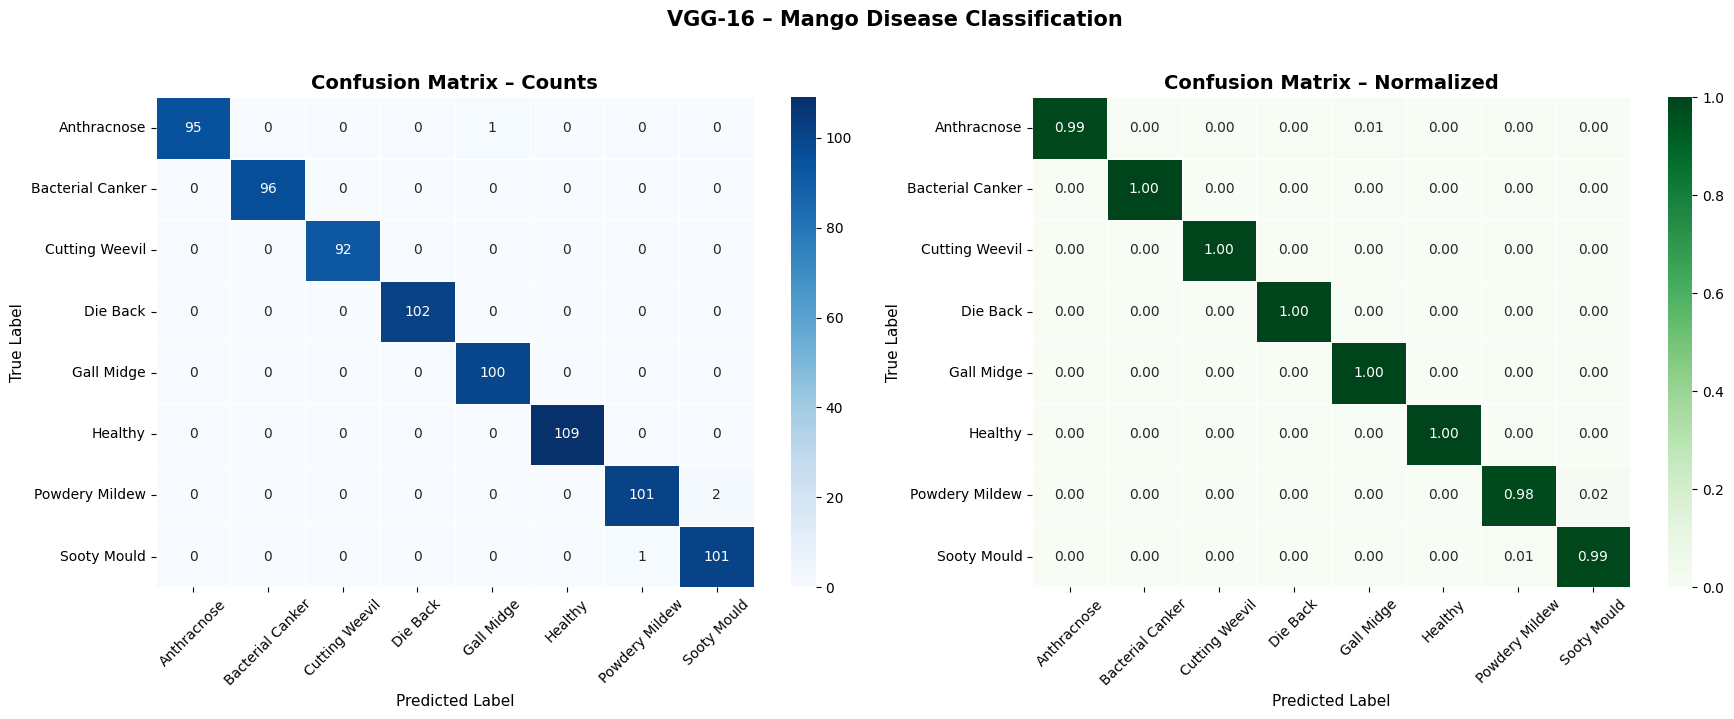


Classification Report:
                  precision    recall  f1-score   support

     Anthracnose       1.00      0.99      0.99        96
Bacterial Canker       1.00      1.00      1.00        96
  Cutting Weevil       1.00      1.00      1.00        92
        Die Back       1.00      1.00      1.00       102
      Gall Midge       0.99      1.00      1.00       100
         Healthy       1.00      1.00      1.00       109
  Powdery Mildew       0.99      0.98      0.99       103
     Sooty Mould       0.98      0.99      0.99       102

        accuracy                           0.99       800
       macro avg       1.00      1.00      1.00       800
    weighted avg       1.00      0.99      0.99       800



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predicciones
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Matriz de confusion
class_names = ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back',
               'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) 

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Conteos
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion Matrix – Counts", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Recall por clase
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Greens",
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=1
)
axes[1].set_title("Confusion Matrix – Normalized", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Predicted Label", fontsize=11)
axes[1].set_ylabel("True Label", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("VGG-16 – Mango Disease Classification", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Reporte de Clasificacion
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Conclusion

A pesar de las limitaciones de tiempo, el modelo logro mostrar un muy alto nivel de capacidad de deteccion. Con una metrica de precision f1 mayor a 0.99, nos indica que no hubo overfitting en el modelo o sus efectos no son relevantes. Esto nos indica que la arquitectura planteada y los pesos pre-entrenados de vgg-16 fueron los adecuados y que fueron implementados exitosamente.